# A/B Testing Marketing Project

## 1. Business Understanding
Objective: Determine which marketing campaign variant (A or B) drives higher engagement and conversion.

#### Business questions:
1. Which campaign version leads to higher conversion rates?
2. Does the winning variant increase revenue per user?
3. Are there demographic segments that respond differently to the campaigns?
4. Success criteria:
5. Statistically significant lift in conversion rate for one variant
6. Positive impact on secondary metrics (click-through rate, revenue per user)
7. Actionable recommendation for campaign rollout

## 2. Data Understanding
- Dataset sources:
- Messy marketing dataset from Fanaka Real Estate.
- Columns include:
- user_id – unique identifier
- group – control or variant
- clicks – number of clicks per user
- views – number of ad views
- converted – 1 if converted, 0 otherwise
- age, gender, location – demographic info

In [5]:
# import necessary libraries
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
import math


# Global config — change once, applies everywhere
ALPHA = 0.05
CONFIDENCE_LEVEL = 1 - ALPHA          # 0.95
MARGIN_OF_ERROR = 0.01                # tighter = more reliable
N_BOOTSTRAP = 5000                    # iterations for bootstrap tests
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

plt.style.use('seaborn-whitegrid')
print('Setup complete.')


Setup complete.


In [6]:
# Load data from a CSV file and print the first 5 rows
data = pd.read_csv('marketing_AB.csv')

In [7]:
# Display the first 5 rows of the dataset
data.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [8]:
# Display the last 5 rows of the dataset
data.tail()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
588096,588096,1278437,ad,False,1,Tuesday,23
588097,588097,1327975,ad,False,1,Tuesday,23
588098,588098,1038442,ad,False,3,Tuesday,23
588099,588099,1496395,ad,False,1,Tuesday,23
588100,588100,1237779,ad,False,1,Tuesday,23


In [9]:
# check the shape of the dataset
data.shape

(588101, 7)

In [10]:
# check the info of the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


In [11]:
# check the data types of each column
data.dtypes

Unnamed: 0        int64
user id           int64
test group       object
converted          bool
total ads         int64
most ads day     object
most ads hour     int64
dtype: object

In [12]:
#check statistical summary of the dataset
data.describe()

,Unnamed: 0,user id,total ads,most ads hour
count,588101.000000,5.881010e+05,588101.000000,588101.000000
mean,294050.000000,1.310692e+06,24.820876,14.469061
std,169770.279667,2.022260e+05,43.715181,4.834634
min,0.000000,9.000000e+05,1.000000,0.000000
25%,147025.000000,1.143190e+06,4.000000,11.000000
50%,294050.000000,1.313725e+06,13.000000,14.000000
75%,441075.000000,1.484088e+06,27.000000,18.000000
max,588100.000000,1.654483e+06,2065.000000,23.000000


In [13]:
# check for missing values
data.isnull().sum()

Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

In [14]:
# check for unique values in each column
data.nunique()

Unnamed: 0       588101
user id          588101
test group            2
converted             2
total ads           807
most ads day          7
most ads hour        24
dtype: int64

In [15]:
# check for duplicate rows
data.duplicated().sum()

0

Text(0.5, 0, 'Test Group')

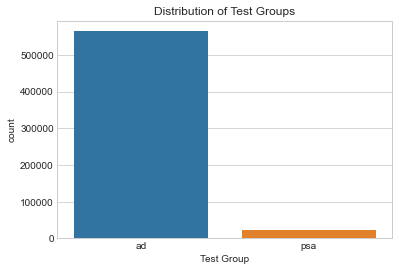

In [16]:
# check of imbalanced test groups
data['test group'].value_counts()
# visualize the distribution of test groups
plt.figure(figsize=(6, 4))
sns.countplot(x='test group', data=data)
plt.title('Distribution of Test Groups')
plt.xlabel('Test Group')

#### conclusions
1. the data doesn't have missing values
2. The data doesn't have duplicated rows

## EDA

In [17]:
# Rename columns for better readability
data = data.rename(columns={
    'user id': 'user_id',
    'test group': 'test_group',
    'converted': 'converted',
    'total ads' : 'total_ads',
    'most ads day': 'most_ads_day',
    'most ads hour': 'most_ads_hour'
})

Text(0, 0.5, 'Conversion Rate')

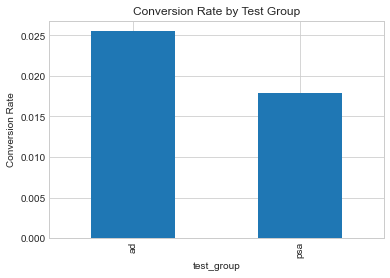

In [18]:
# conversion rate by test group
conversion_rate = data.groupby('test_group')['converted'].mean()
conversion_rate.plot(kind='bar', title='Conversion Rate by Test Group')
plt.ylabel('Conversion Rate')

<AxesSubplot:xlabel='total_ads', ylabel='Count'>

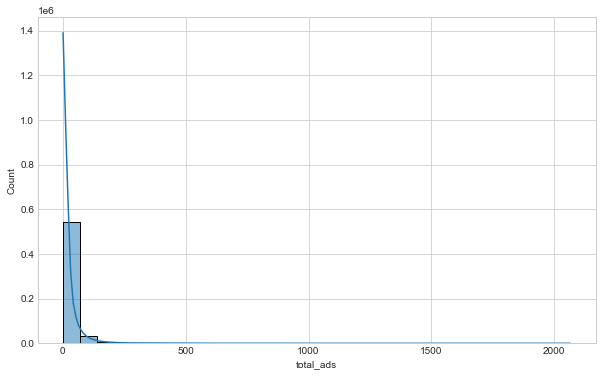

In [19]:
# Distribution of total ads seen
plt.figure(figsize=(10, 6))
sns.histplot(data['total_ads'], bins=30, kde=True)  

Text(0, 0.5, 'Conversion Rate')

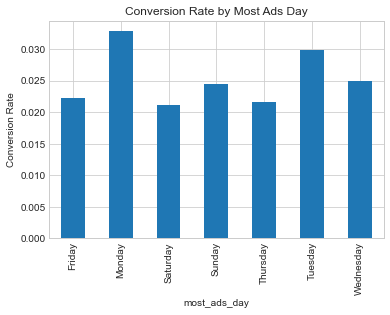

In [20]:
# conversion rate by most ads day
conversion_rate_day = data.groupby('most_ads_day')['converted'].mean()
conversion_rate_day.plot(kind='bar', title='Conversion Rate by Most Ads Day')
plt.ylabel('Conversion Rate')

Text(0, 0.5, 'Conversion Rate')

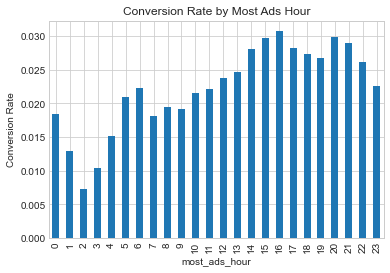

In [21]:
# conversion rate by most ads per hour
conversion_rate_hour = data.groupby('most_ads_hour')['converted'].mean()
conversion_rate_hour.plot(kind='bar', title='Conversion Rate by Most Ads Hour')
plt.ylabel('Conversion Rate')


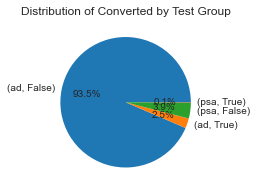

In [22]:
grouped_counts = data.groupby('test_group')['converted'].value_counts()
grouped_counts

# Plot the data as a pie chart
grouped_counts.plot.pie(figsize= (3,3),autopct='%1.1f%%')

# Set the title and axis labels
plt.title('Distribution of Converted by Test Group')
plt.ylabel('')

# Show the plot
plt.show()

### 3. Data Preparation

In [23]:
# check for the uniformity of column names
data.columns

Index(['Unnamed: 0', 'user_id', 'test_group', 'converted', 'total_ads',
       'most_ads_day', 'most_ads_hour'],
      dtype='object')

In [24]:
data = data.drop(columns=['Unnamed: 0'])
data.columns

Index(['user_id', 'test_group', 'converted', 'total_ads', 'most_ads_day',
       'most_ads_hour'],
      dtype='object')

In [25]:
# convert the 'converted' column to integer type (1 for True, 0 for False)
data["converted_int"] = data['converted'].apply(lambda x:1 if x== True  else  0)
data["converted_int"].sum()

14843

In [26]:
data.head()

,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour,converted_int
0,1069124,ad,False,130,Monday,20,0
1,1119715,ad,False,93,Tuesday,22,0
2,1144181,ad,False,21,Tuesday,18,0
3,1435133,ad,False,355,Tuesday,10,0
4,1015700,ad,False,276,Friday,14,0


### Sample Size Validation

In [ ]:
# Check for minimum sample size per group
def required_sample_size(population_size, confidence_level, margin_of_error, p=0.5):
    """
    Returns the minimum sample size per group.
    Uses conservative p=0.5 by default.
    """
    z_table = {0.90: 1.645, 0.95: 1.96, 0.99: 2.576}
    if confidence_level not in z_table:
        raise ValueError(f'Confidence level must be one of {list(z_table.keys())}')
    z = z_table[confidence_level]
    q = 1 - p
    n = (z**2 * p * q * population_size) / (
        (z**2 * p * q) + (margin_of_error**2 * (population_size - 1))
    )
    return math.ceil(n)


def validate_sample_sizes(data, group_col, confidence_level, margin_of_error):
    """
    Compares actual group sizes against the required minimum.
    Prints a clear pass/fail per group.
    """
    pop_size = len(data)
    min_required = required_sample_size(pop_size, confidence_level, margin_of_error)
    print(f'Population     : {pop_size:,}')
    print(f'Min required   : {min_required:,}  (conf={confidence_level}, moe={margin_of_error})')
    print()
    all_ok = True
    for group, grp_data in data.groupby(group_col):
        n = len(grp_data)
        status = 'PASS' if n >= min_required else 'FAIL'
        if status == 'FAIL':
            all_ok = False
        print(f'  [{status}] {group}: n={n:,}  (need >= {min_required:,})')
    print()
    if not all_ok:
        print('WARNING: One or more groups are undersized. Results may be unreliable.')
    else:
        print('All groups meet the minimum sample size. Proceed with testing.')
    return all_ok


validate_sample_sizes(data, 'test_group', CONFIDENCE_LEVEL, MARGIN_OF_ERROR)

Population     : 588,101
Min required   : 9,450  (conf=0.95, moe=0.01)

  [PASS] ad: n=564,577  (need >= 9,450)
  [PASS] psa: n=23,524  (need >= 9,450)

All groups meet the minimum sample size. Proceed with testing.


True

### 4. A/B Testing

### Core Metrics

In [ ]:
# Calculate conversion rates and lifts
treatment = data[data['test_group'] == 'ad'].copy()
control   = data[data['test_group'] == 'psa'].copy()

ad_rate  = treatment['converted'].mean()
psa_rate = control['converted'].mean()
abs_lift = ad_rate - psa_rate
rel_lift = abs_lift / psa_rate * 100  # relative lift in %

print(f'PSA conversion rate  : {psa_rate:.4%}')
print(f'Ad  conversion rate  : {ad_rate:.4%}')
print(f'Absolute lift        : {abs_lift:.4%}')
print(f'Relative lift        : +{rel_lift:.1f}%')

PSA conversion rate  : 1.7854%
Ad  conversion rate  : 2.5547%
Absolute lift        : 0.7692%
Relative lift        : +43.1%


### Statistical Tests
#### Three methods are used. All must agree before drawing a conclusion.

In [ ]:
# Perform a two-proportion z-test
def print_result(test_name, p_value, alpha):
    decision = 'REJECT H0' if p_value < alpha else 'FAIL TO REJECT H0'
    print(f'[{test_name}]')
    print(f'  p-value  : {p_value:.6f}')
    print(f'  alpha    : {alpha}')
    print(f'  Decision : {decision}')
    print()

Welch's T-Test

In [61]:
# Welch's t-test does not assume equal variances — more appropriate here
t_stat, t_pvalue = stats.ttest_ind(
    treatment['converted'],
    control['converted'],
    equal_var=False,
    alternative='greater'   # one-sided: ad > psa
)

print(f'T-statistic: {t_stat:.4f}')
print_result("Welch's T-Test", t_pvalue, ALPHA)

T-statistic: 8.6572
[Welch's T-Test]
  p-value  : 0.000000
  alpha    : 0.05
  Decision : REJECT H0



#### Chi-Square Test

Chi-square: 54.0058  |  Degrees of freedom: 1
[Chi-Square Test]
  p-value  : 0.000000
  alpha    : 0.05
  Decision : REJECT H0



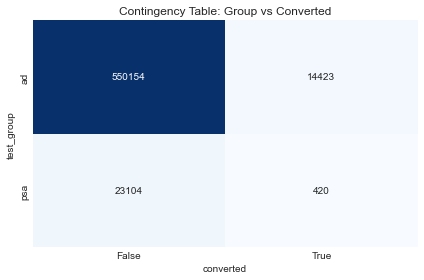

In [62]:
# Build contingency table without margins (chi2_contingency needs raw counts)
ct = pd.crosstab(data['test_group'], data['converted'])

chi2, chi_pvalue, dof, expected = stats.chi2_contingency(ct)

print(f'Chi-square: {chi2:.4f}  |  Degrees of freedom: {dof}')
print_result('Chi-Square Test', chi_pvalue, ALPHA)

# Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Contingency Table: Group vs Converted')
plt.tight_layout()
plt.savefig('chi2_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

#### Bootstrap Permutation Test

[Bootstrap Permutation Test]
  p-value  : 0.000000
  alpha    : 0.05
  Decision : REJECT H0



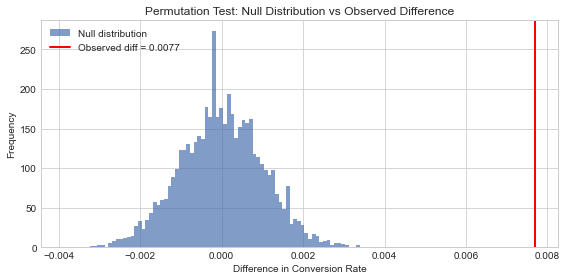

In [ ]:
# Visualise expected counts vs observed counts
def permutation_test(group_a, group_b, n_iterations, observed_diff, seed=42):
    """
    Shuffles group labels N times and measures how often the
    simulated difference exceeds the observed difference.
    Returns the one-sided p-value.
    """
    np.random.seed(seed)
    combined = np.concatenate([group_a, group_b])
    n_a = len(group_a)
    null_diffs = np.empty(n_iterations)

    for i in range(n_iterations):
        shuffled = np.random.permutation(combined)
        null_diffs[i] = shuffled[:n_a].mean() - shuffled[n_a:].mean()

    p_value = (null_diffs >= observed_diff).mean()
    return p_value, null_diffs


boot_pvalue, null_diffs = permutation_test(
    treatment['converted'].values,
    control['converted'].values,
    N_BOOTSTRAP,
    abs_lift
)

print_result('Bootstrap Permutation Test', boot_pvalue, ALPHA)

# Visualise null distribution
plt.figure(figsize=(8, 4))
plt.hist(null_diffs, bins=80, color='#4C72B0', alpha=0.7, label='Null distribution')
plt.axvline(abs_lift, color='red', linewidth=2, label=f'Observed diff = {abs_lift:.4f}')
plt.title('Permutation Test: Null Distribution vs Observed Difference')
plt.xlabel('Difference in Conversion Rate')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('permutation_test.png', dpi=150, bbox_inches='tight')
plt.show()

### Effect Size and Confidence Interval

In [ ]:
# Calculate effect size and confidence intervals
def cohens_h(p1, p2):
    """Effect size for two proportions."""
    return 2 * (math.asin(math.sqrt(p1)) - math.asin(math.sqrt(p2)))


def proportion_confidence_interval(p, n, confidence_level):
    """Wilson score confidence interval."""
    z_table = {0.90: 1.645, 0.95: 1.96, 0.99: 2.576}
    z = z_table[confidence_level]
    denominator = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denominator
    margin  = (z * math.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))) / denominator
    return centre - margin, centre + margin


h = cohens_h(ad_rate, psa_rate)
h_label = 'small' if abs(h) < 0.2 else ('medium' if abs(h) < 0.5 else 'large')

ad_ci  = proportion_confidence_interval(ad_rate,  len(treatment), CONFIDENCE_LEVEL)
psa_ci = proportion_confidence_interval(psa_rate, len(control),   CONFIDENCE_LEVEL)

print(f"Effect size (Cohen's h) : {h:.4f}  [{h_label}]")
print()
print(f'Ad  rate CI ({int(CONFIDENCE_LEVEL*100)}%) : [{ad_ci[0]:.4%}, {ad_ci[1]:.4%}]')
print(f'PSA rate CI ({int(CONFIDENCE_LEVEL*100)}%) : [{psa_ci[0]:.4%}, {psa_ci[1]:.4%}]')

Effect size (Cohen's h) : 0.0530  [small]

Ad  rate CI (95%) : [2.5138%, 2.5961%]
PSA rate CI (95%) : [1.6239%, 1.9627%]


### Business Summary

In [ ]:
# Final business summary
def business_summary(ad_rate, psa_rate, abs_lift, rel_lift, h, h_label,
                     t_pvalue, chi_pvalue, boot_pvalue, alpha,
                     ad_ci, psa_ci):

    all_significant = all(p < alpha for p in [t_pvalue, chi_pvalue, boot_pvalue])

    print('=' * 60)
    print('BUSINESS SUMMARY')
    print('=' * 60)
    print(f'  PSA conversion rate   : {psa_rate:.2%}')
    print(f'  Ad  conversion rate   : {ad_rate:.2%}')
    print(f'  Absolute lift         : +{abs_lift:.2%}')
    print(f'  Relative lift         : +{rel_lift:.1f}%')
    print(f"  Effect size           : Cohen's h = {h:.4f}  [{h_label}]")
    print()
    print('  Confidence intervals (95%):')
    print(f'    Ad  : [{ad_ci[0]:.2%}, {ad_ci[1]:.2%}]')
    print(f'    PSA : [{psa_ci[0]:.2%}, {psa_ci[1]:.2%}]')
    print()
    print('  Statistical tests:')
    print(f"    Welch's T-Test        : p={t_pvalue:.6f}")
    print(f'    Chi-Square Test       : p={chi_pvalue:.6f}')
    print(f'    Bootstrap Permutation : p={boot_pvalue:.6f}')
    print()
    print('  Conclusion:')
    if all_significant:
        print('    All three tests reject H0.')
        print('    The ad campaign drives significantly more conversions.')
        print('    Recommendation: Roll out the ad campaign.')
        print(f'    Expected uplift: {abs_lift:.2%} more conversions per user.')
    else:
        print('    Not all tests agree. Do not roll out yet.')
        print('    Collect more data or re-examine experiment design.')
    print('=' * 60)


business_summary(
    ad_rate, psa_rate, abs_lift, rel_lift, h, h_label,
    t_pvalue, chi_pvalue, boot_pvalue, ALPHA,
    ad_ci, psa_ci
)

BUSINESS SUMMARY
  PSA conversion rate   : 1.79%
  Ad  conversion rate   : 2.55%
  Absolute lift         : +0.77%
  Relative lift         : +43.1%
  Effect size           : Cohen's h = 0.0530  [small]

  Confidence intervals (95%):
    Ad  : [2.51%, 2.60%]
    PSA : [1.62%, 1.96%]

  Statistical tests:
    Welch's T-Test        : p=0.000000
    Chi-Square Test       : p=0.000000
    Bootstrap Permutation : p=0.000000

  Conclusion:
    All three tests reject H0.
    The ad campaign drives significantly more conversions.
    Recommendation: Roll out the ad campaign.
    Expected uplift: 0.77% more conversions per user.
